In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import interp1d

In [ ]:
import numpy as np
from scipy.signal import argrelmin
from scipy.ndimage import uniform_filter1d

df = pd.read_parquet('./data/1CFF_MSE_set4.parquet')

def find_significant_minima(x_s, y_s, min_depth_fraction=0.1, order=10):
    y_smooth = uniform_filter1d(y_s, size=order)
    local_min_idx = argrelmin(y_smooth, order=order)[0]
    threshold = min_depth_fraction * y_s.max()
    significant = [(x_s[i], y_s[i]) for i in local_min_idx
                   if y_s[i] < threshold]
    return sorted(significant, key=lambda m: m[1])


def window_around_minimum(x_s, y_s, x_min, half_width):
    mask = np.abs(x_s - x_min) <= half_width
    x_w, y_w = x_s[mask], y_s[mask]
    # shift y to zero at x_min specifically
    idx_min = np.argmin(np.abs(x_w - x_min))
    y_w = y_w - y_w[idx_min]
    return x_w, y_w


def analyze_dataset(x_vals, y_vals,
                    window_half_width=10,
                    min_depth_fraction=0.1,
                    similar_depth_tolerance=2.0):

    T_LO_RATIO = 10.0
    T_HI_RATIO = 1e5

    sort_idx = np.argsort(x_vals)
    x_s, y_s = x_vals[sort_idx], y_vals[sort_idx]

    minima = find_significant_minima(x_s, y_s, min_depth_fraction)
    if len(minima) == 0:
        return [{"minimum": np.nan, "mean": np.nan, "sigma": np.nan,
                 "curvature": np.nan, "status": "no minimum found"}]

    deepest_y = minima[0][1]
    selected = [m for m in minima
                if (m[1] - deepest_y) < similar_depth_tolerance
                or deepest_y == 0]

    results = []
    for x_min, y_min in selected:

        # window and shift y to zero at this minimum
        mask = np.abs(x_s - x_min) <= window_half_width
        x_w = x_s[mask]
        y_w = y_s[mask].copy()
        idx_min = np.argmin(np.abs(x_w - x_min))
        y_w = y_w - y_w[idx_min]

        max_L = y_w.max()
        if max_L <= 0:
            results.append({"minimum": x_min, "mean": np.nan,
                            "sigma": np.nan, "curvature": np.nan,
                            "status": "flat window"})
            continue

        T_lo  = max_L / T_HI_RATIO
        T_hi  = max_L / T_LO_RATIO
        T_mid = np.sqrt(T_lo * T_hi)

        if T_lo >= T_hi:
            results.append({"minimum": x_min, "mean": np.nan,
                            "sigma": np.nan, "curvature": np.nan,
                            "status": f"no valid T: max(L)={max_L:.2e}"})
            continue

        # compute mean, sigma at three T values
        T_vals   = [T_lo, T_mid, T_hi]
        sigmas, means, curvatures = [], [], []

        for T in T_vals:
            log_p  = -y_w / T
            log_p -= log_p.max()
            p      = np.exp(log_p)
            norm   = np.trapz(p, x_w)
            if norm == 0:
                continue
            p  /= norm
            m   = np.trapz(p * x_w, x_w)
            s   = np.sqrt(np.trapz(p * (x_w - m)**2, x_w))
            means.append(m)
            sigmas.append(s)
            if s > 0:
                curvatures.append(T / (2 * s**2))  # a = T/2σ²

        if len(curvatures) < 2:
            results.append({"minimum": x_min, "mean": np.nan,
                            "sigma": np.nan, "curvature": np.nan,
                            "status": "numerical failure"})
            continue

        # stability check on curvature, not sigma
        curv_mean   = np.mean(curvatures)
        curv_spread = (max(curvatures) - min(curvatures)) / curv_mean

        # T-independent shape descriptor
        sigma_intrinsic = 1.0 / np.sqrt(2 * curv_mean)

        if curv_spread > 0.3:
            status = (f"WARNING: non-parabolic "
                      f"(curvature spread={curv_spread:.0%})")
        else:
            status = f"OK (curvature spread={curv_spread:.0%})"

        results.append({
            "minimum":          x_min,
            "mean":             means[1],           # at T_mid
            "sigma":            sigmas[1],           # at T_mid, for reference
            "sigma_intrinsic":  sigma_intrinsic,     # T-independent
            "curvature":        curv_mean,           # a = T/2σ², T-independent
            "curv_spread":      curv_spread,
            "max_L":            max_L,
            "status":           status,
        })

    return results


# --- main loop ---
for index in range(8):
    dfcff = df[df['index'] == index]
    x_vals = dfcff['cff'].values
    y_vals = (dfcff['chi2'] - dfcff['chi2'].min()).values

    results = analyze_dataset(x_vals, y_vals, window_half_width=10)

    print(f"\nDataset {index}:")
    for r in results:
        if np.isnan(r['sigma']):
            print(f"  x*={r['minimum']:.3f} | {r['status']}")
        else:
            print(f"  x*={r['minimum']:+8.3f} | "
                  f"mean={r['mean']:+8.4f} | "
                  f"sigma_intrinsic={r['sigma_intrinsic']:.4f} | "
                  f"curvature={r['curvature']:.4e} | "
                  f"{r['status']}")


Dataset 0:
  x*=  -2.495 | mean= -2.5477 | sigma_intrinsic=13.8010 | curvature=2.6251e-03 | WARNING: non-parabolic (curvature spread=94%)

Dataset 1:
  x*=  +1.371 | mean= +1.4223 | sigma_intrinsic=8.6687 | curvature=6.6537e-03 | WARNING: non-parabolic (curvature spread=33%)
  x*=  +9.775 | mean= +1.3492 | sigma_intrinsic=4.6592 | curvature=2.3033e-02 | WARNING: non-parabolic (curvature spread=263%)

Dataset 2:
  x*=  +2.183 | mean= +2.1829 | sigma_intrinsic=207.4851 | curvature=1.1614e-05 | OK (curvature spread=2%)

Dataset 3:
  x*=+126.556 | mean=+126.2789 | sigma_intrinsic=34.3524 | curvature=4.2370e-04 | WARNING: non-parabolic (curvature spread=290%)
  x*= -74.043 | mean=-74.4584 | sigma_intrinsic=178.9966 | curvature=1.5606e-05 | OK (curvature spread=3%)

Dataset 4:
  x*=  +3.215 | mean= +3.0902 | sigma_intrinsic=12.4303 | curvature=3.2360e-03 | WARNING: non-parabolic (curvature spread=67%)

Dataset 5:
  x*=  +1.508 | mean= +0.6221 | sigma_intrinsic=15.9507 | curvature=1.9652e-03

/tmp/ipykernel_251580/1780040287.py:81: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm   = np.trapz(p, x_w)
/tmp/ipykernel_251580/1780040287.py:85: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  m   = np.trapz(p * x_w, x_w)
/tmp/ipykernel_251580/1780040287.py:86: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  s   = np.sqrt(np.trapz(p * (x_w - m)**2, x_w))


In [33]:
from scipy.interpolate import interp1d

delta = 1.0  # one unit of chi-squared = 1-sigma by definition

for index in range(8):
    dfcff = df[df['index'] == index]
    x_vals = dfcff['cff'].values
    y_vals = (dfcff['chi2'] - dfcff['chi2'].min()).values

    sort_idx = np.argsort(x_vals)
    x_s, y_s = x_vals[sort_idx], y_vals[sort_idx]
    idx_min = np.argmin(y_s)
    x_min = x_s[idx_min]

    left_x,  left_y  = x_s[:idx_min][::-1], y_s[:idx_min][::-1]
    right_x, right_y = x_s[idx_min:],        y_s[idx_min:]

    # check if delta is reachable on each side
    left_reached  = left_y.max()  >= delta
    right_reached = right_y.max() >= delta

    if left_reached and right_reached:
        x_left  = float(interp1d(left_y,  left_x)(delta))
        x_right = float(interp1d(right_y, right_x)(delta))
        half_width = (x_right - x_left) / 2.0
        print(f"Dataset {index}: x*={x_min:.4f}, "
              f"1-sigma uncertainty = ±{half_width:.4f} cff units")
    else:
        # report lower bound: uncertainty is larger than window extent
        window_extent = max(x_s.max() - x_min, x_min - x_s.min())
        print(f"Dataset {index}: x*={x_min:.4f}, "
              f"1-sigma uncertainty > ±{window_extent:.1f} cff units "
              f"(chi-sq never rises by 1 in your grid — "
              f"max delta-chi2 = {y_s.max():.2e})")

Dataset 0: x*=-2.5250, 1-sigma uncertainty = ±11.0780 cff units
Dataset 1: x*=1.3457, 1-sigma uncertainty > ±14.0 cff units (chi-sq never rises by 1 in your grid — max delta-chi2 = 8.09e+00)
Dataset 2: x*=2.1834, 1-sigma uncertainty > ±16.5 cff units (chi-sq never rises by 1 in your grid — max delta-chi2 = 4.14e-03)
Dataset 3: x*=-74.5685, 1-sigma uncertainty > ±337.1 cff units (chi-sq never rises by 1 in your grid — max delta-chi2 = 2.11e+00)
Dataset 4: x*=3.2155, 1-sigma uncertainty = ±11.8686 cff units
Dataset 5: x*=1.5079, 1-sigma uncertainty = ±10.7308 cff units
Dataset 6: x*=0.0000, 1-sigma uncertainty > ±10.0 cff units (chi-sq never rises by 1 in your grid — max delta-chi2 = 1.21e-03)
Dataset 7: x*=0.0000, 1-sigma uncertainty > ±10.0 cff units (chi-sq never rises by 1 in your grid — max delta-chi2 = 1.81e-04)


/home/ptgroup/miniconda3/envs/pratik_env/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/ptgroup/miniconda3/envs/pratik_env/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


Dataset 0: mean = -0.0040, sigma = 0.1669, GD steps: 166.9066
Dataset 1: mean = 0.0025, sigma = 0.0879, GD steps: 87.9134
Dataset 2: mean = 0.0448, sigma = 2.0659, GD steps: 2065.8621
Dataset 3: mean = -100.3545, sigma = 100.3232, GD steps: 100323.1484
Dataset 4: mean = -0.0067, sigma = 0.1347, GD steps: 134.7387
Dataset 5: mean = -0.0552, sigma = 0.2640, GD steps: 263.9816
Dataset 6: mean = 0.4369, sigma = 2.6065, GD steps: 2606.5100
Dataset 7: mean = 0.5315, sigma = 4.8166, GD steps: 4816.5864


/tmp/ipykernel_1683285/2569416209.py:63: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  p /= np.trapz(p, x_vals)
/tmp/ipykernel_1683285/2569416209.py:66: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  mean = np.trapz(p * x_vals, x_vals)
/tmp/ipykernel_1683285/2569416209.py:67: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  variance = np.trapz(p * (x_vals - mean)**2, x_vals)


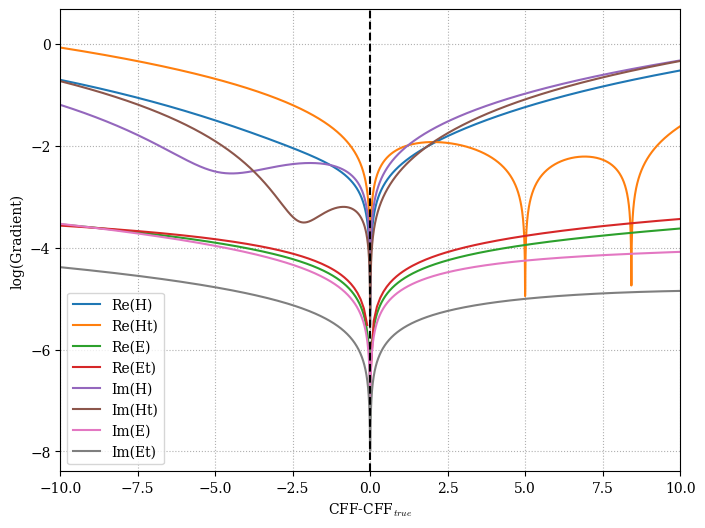

<Figure size 640x480 with 0 Axes>

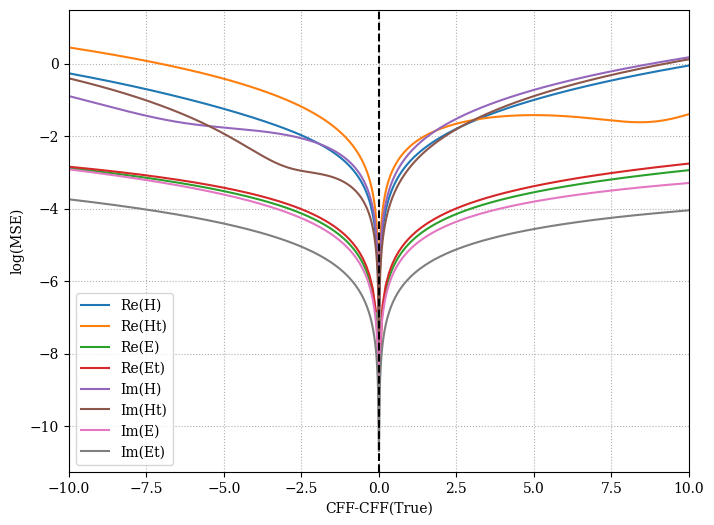

In [25]:
names = ['Re(H)','Re(Ht)','Re(E)','Re(Et)','Im(H)','Im(Ht)','Im(E)','Im(Et)']

import matplotlib as mpl
mpl.rcParams.update({
    "text.usetex": False,
    "mathtext.fontset": "cm",   # ← this gives you Computer Modern math
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],  # ← fallback that EXISTS
})

uncertainties = []
means = []

fig,ax= plt.subplots(1,1,figsize=(8, 6))
df = pd.read_parquet('./data/1CFF_MSE_set4.parquet')

# plt.ylim([-0.5, 0.5])
plt.xlim([-10, 10])
index = 0

for index in range(8):
    dfcff = df[df['index']==index]
    plt.plot(dfcff['cff']-dfcff['true_cff'], np.log10(abs(dfcff['G'])), label=names[index])
    # plt.plot(dfcff['cff']-dfcff['true_cff'], np.log10(dfcff['G']/(dfcff['chi2']*1e-7)))
plt.axvline(dfcff['true_cff'].values[0], ls='--', c='k')
plt.grid(ls=':')
plt.legend()
plt.ylabel('log(Gradient)')
plt.xlabel(r'CFF-CFF$_{true}$')
plt.savefig('./figs/1CFF_grad.pdf')

plt.figure()
fig,ax= plt.subplots(1,1,figsize=(8, 6))
plt.xlim([-10,10])
plt.ylabel('log(MSE)')
plt.xlabel(r'CFF-CFF(True)')

# plt.ylim([0,0.5])

for index in range(8):
    dfcff = df[df['index']==index]
    x = dfcff['cff']-dfcff['true_cff']
    y = np.log10(dfcff['chi2']-min(dfcff['chi2']))
    plt.plot(x,y, label=names[index])
# plt.yscale('log')
plt.axvline(dfcff['true_cff'].values[0], ls='--', c='k')

plt.grid(ls=':')
plt.legend()

def loss_to_distribution(x_vals, y_vals, T=None):
    if T is None:
        T = np.max(y_vals) * 1.2e-7  # float32 noise floor
    
    # compute unnormalized log probabilities
    log_p = -y_vals / T
    
    # subtract max for numerical stability before exp
    log_p -= log_p.max()
    p = np.exp(log_p)
    
    # normalize
    p /= np.trapz(p, x_vals)
    
    # mean and std of distribution
    mean = np.trapz(p * x_vals, x_vals)
    variance = np.trapz(p * (x_vals - mean)**2, x_vals)
    sigma = np.sqrt(variance)
    
    return p, mean, sigma

plt.savefig('./figs/1CFF_loss.pdf')

for index in range(8):
    dfcff = df[df['index'] == index]
    x_vals = (dfcff['cff'] - dfcff['true_cff']).values
    y_vals = (dfcff['chi2'] - dfcff['chi2'].min()).values
    
    sort_idx = np.argsort(x_vals)
    x_s, y_s = x_vals[sort_idx], y_vals[sort_idx]
    
    p, mean, sigma = loss_to_distribution(x_s, y_s, 1e-4)
    print(f"Dataset {index}: mean = {mean:.4f}, sigma = {sigma:.4f}, GD steps: {sigma/1e-3:.4f}")